# 💳 Credit Card Fraud Detection
## Full Production-Level ML Pipeline

**Dataset:** [Kaggle — Credit Card Fraud Detection](https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud)  
**Goal:** Detect fraudulent transactions using ML with explainability  
**Stack:** Pandas, Scikit-learn, XGBoost, LightGBM, SHAP, MLflow, FastAPI

---

### Pipeline Overview
1. 📥 Data Loading & Overview
2. 🔍 Exploratory Data Analysis (EDA)
3. ⚙️ Feature Engineering
4. 🧹 Preprocessing & Imbalance Handling
5. 🤖 Model Training & Comparison
6. 📊 Evaluation & SHAP Explainability
7. 🚀 FastAPI Deployment


In [1]:
# ── Imports ──────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    confusion_matrix, classification_report,
    roc_auc_score, average_precision_score,
    precision_recall_curve, roc_curve, f1_score
)
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from imblearn.over_sampling import SMOTE
import shap
import mlflow
import mlflow.sklearn

plt.style.use("seaborn-v0_8-darkgrid")
pd.set_option("display.float_format", "{:.4f}".format)
print("✅ All imports successful")


✅ All imports successful


## 📥 1. Data Loading

In [2]:
# Download from Kaggle (make sure kaggle.json is configured)
# import kaggle
# kaggle.api.dataset_download_files("mlg-ulb/creditcardfraud", path="data/", unzip=True)
import os
os.chdir(r"C:\Users\Hp\Desktop\ML_projects\files")

# Load the dataset
df = pd.read_csv("data/creditcard.csv")
print(f"Shape: {df.shape}")
df.head()


Shape: (284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0000,-1.3598,-0.0728,2.5363,1.3782,-0.3383,0.4624,0.2396,0.0987,0.3638,...,-0.0183,0.2778,-0.1105,0.0669,0.1285,-0.1891,0.1336,-0.0211,149.6200,0
1,0.0000,1.1919,0.2662,0.1665,0.4482,0.0600,-0.0824,-0.0788,0.0851,-0.2554,...,-0.2258,-0.6387,0.1013,-0.3398,0.1672,0.1259,-0.0090,0.0147,2.6900,0
2,1.0000,-1.3584,-1.3402,1.7732,0.3798,-0.5032,1.8005,0.7915,0.2477,-1.5147,...,0.2480,0.7717,0.9094,-0.6893,-0.3276,-0.1391,-0.0554,-0.0598,378.6600,0
3,1.0000,-0.9663,-0.1852,1.7930,-0.8633,-0.0103,1.2472,0.2376,0.3774,-1.3870,...,-0.1083,0.0053,-0.1903,-1.1756,0.6474,-0.2219,0.0627,0.0615,123.5000,0
4,2.0000,-1.1582,0.8777,1.5487,0.4030,-0.4072,0.0959,0.5929,-0.2705,0.8177,...,-0.0094,0.7983,-0.1375,0.1413,-0.2060,0.5023,0.2194,0.2152,69.9900,0


In [3]:
# Basic Info
print("=" * 50)
print(f"Total Transactions : {len(df):,}")
print(f"Fraud Cases        : {df['Class'].sum():,}")
print(f"Legitimate Cases   : {(df['Class']==0).sum():,}")
print(f"Fraud Percentage   : {df['Class'].mean()*100:.4f}%")
print(f"Missing Values     : {df.isnull().sum().sum()}")
print(f"Time Range         : {df['Time'].min():.0f}s to {df['Time'].max():.0f}s")
print(f"Amount Range       : ${df['Amount'].min():.2f} to ${df['Amount'].max():.2f}")
print("=" * 50)


Total Transactions : 284,807
Fraud Cases        : 492
Legitimate Cases   : 284,315
Fraud Percentage   : 0.1727%
Missing Values     : 0
Time Range         : 0s to 172792s
Amount Range       : $0.00 to $25691.16


## 🔍 2. Exploratory Data Analysis (EDA)

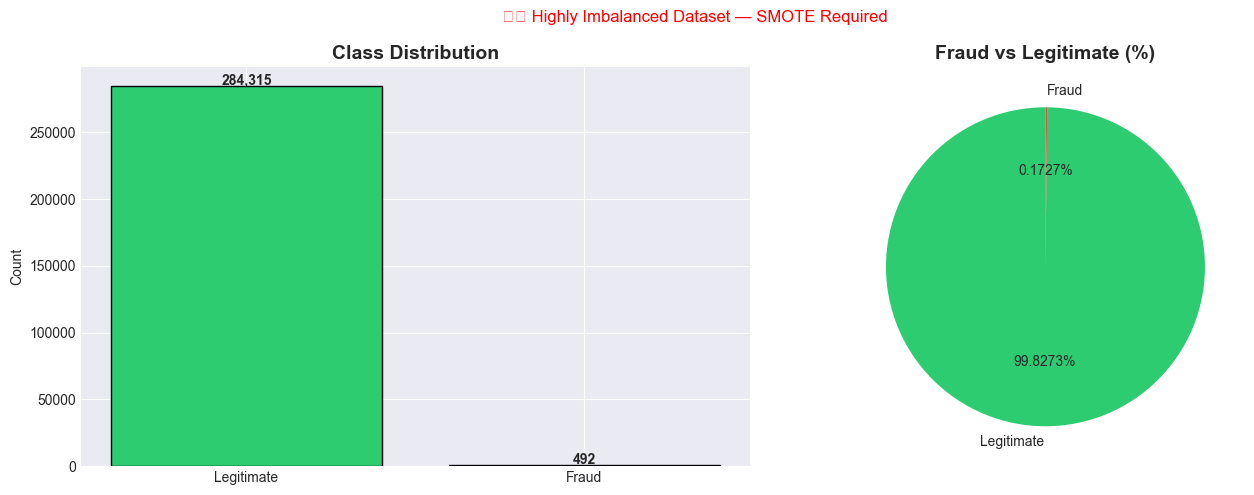

In [4]:
# Class Distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Count plot
counts = df['Class'].value_counts()
bars = axes[0].bar(['Legitimate', 'Fraud'], counts.values, color=['#2ecc71', '#e74c3c'], edgecolor='black')
axes[0].set_title('Class Distribution', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Count')
for bar, count in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1000,
                 f'{count:,}', ha='center', fontweight='bold')

# Percentage pie
axes[1].pie(counts.values, labels=['Legitimate', 'Fraud'],
            colors=['#2ecc71', '#e74c3c'],
            autopct='%1.4f%%', startangle=90)
axes[1].set_title('Fraud vs Legitimate (%)', fontsize=14, fontweight='bold')

plt.suptitle('⚠️ Highly Imbalanced Dataset — SMOTE Required', fontsize=12, color='red')
plt.tight_layout()
plt.savefig('reports/figures/class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()


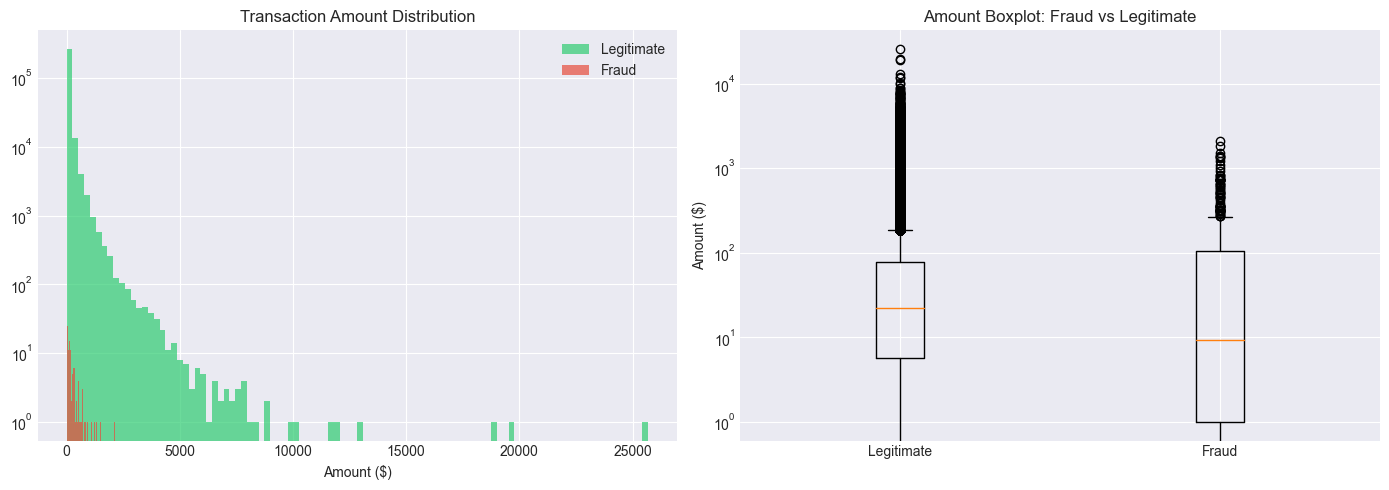

Fraud mean amount   : $122.21
Legit mean amount   : $88.29


In [5]:
# Amount Distribution: Fraud vs Legitimate
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

fraud = df[df['Class'] == 1]['Amount']
legit = df[df['Class'] == 0]['Amount']

axes[0].hist(legit, bins=100, color='#2ecc71', alpha=0.7, label='Legitimate')
axes[0].hist(fraud, bins=100, color='#e74c3c', alpha=0.7, label='Fraud')
axes[0].set_title('Transaction Amount Distribution')
axes[0].set_xlabel('Amount ($)')
axes[0].legend()
axes[0].set_yscale('log')

axes[1].boxplot([legit, fraud], labels=['Legitimate', 'Fraud'])
axes[1].set_title('Amount Boxplot: Fraud vs Legitimate')
axes[1].set_ylabel('Amount ($)')
axes[1].set_yscale('log')

plt.tight_layout()
plt.savefig('reports/figures/amount_distribution.png', dpi=150)
plt.show()

print(f"Fraud mean amount   : ${fraud.mean():.2f}")
print(f"Legit mean amount   : ${legit.mean():.2f}")


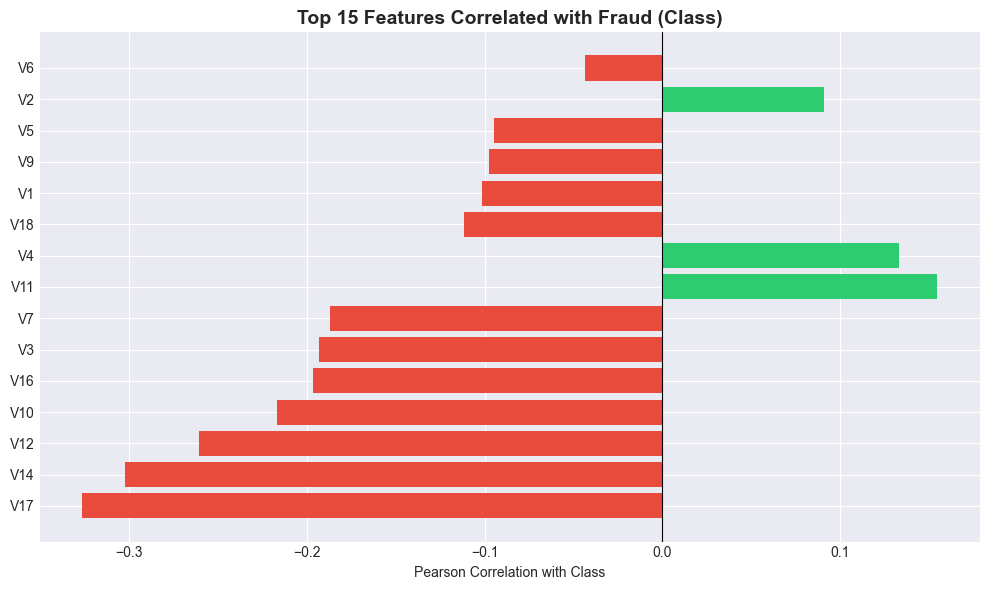

In [6]:
# Correlation Heatmap — Top features correlated with fraud
corr_with_class = df.corr()['Class'].sort_values(key=abs, ascending=False)[1:16]

plt.figure(figsize=(10, 6))
colors = ['#e74c3c' if v < 0 else '#2ecc71' for v in corr_with_class.values]
bars = plt.barh(corr_with_class.index, corr_with_class.values, color=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Top 15 Features Correlated with Fraud (Class)', fontsize=14, fontweight='bold')
plt.xlabel('Pearson Correlation with Class')
plt.tight_layout()
plt.savefig('reports/figures/feature_correlation.png', dpi=150)
plt.show()


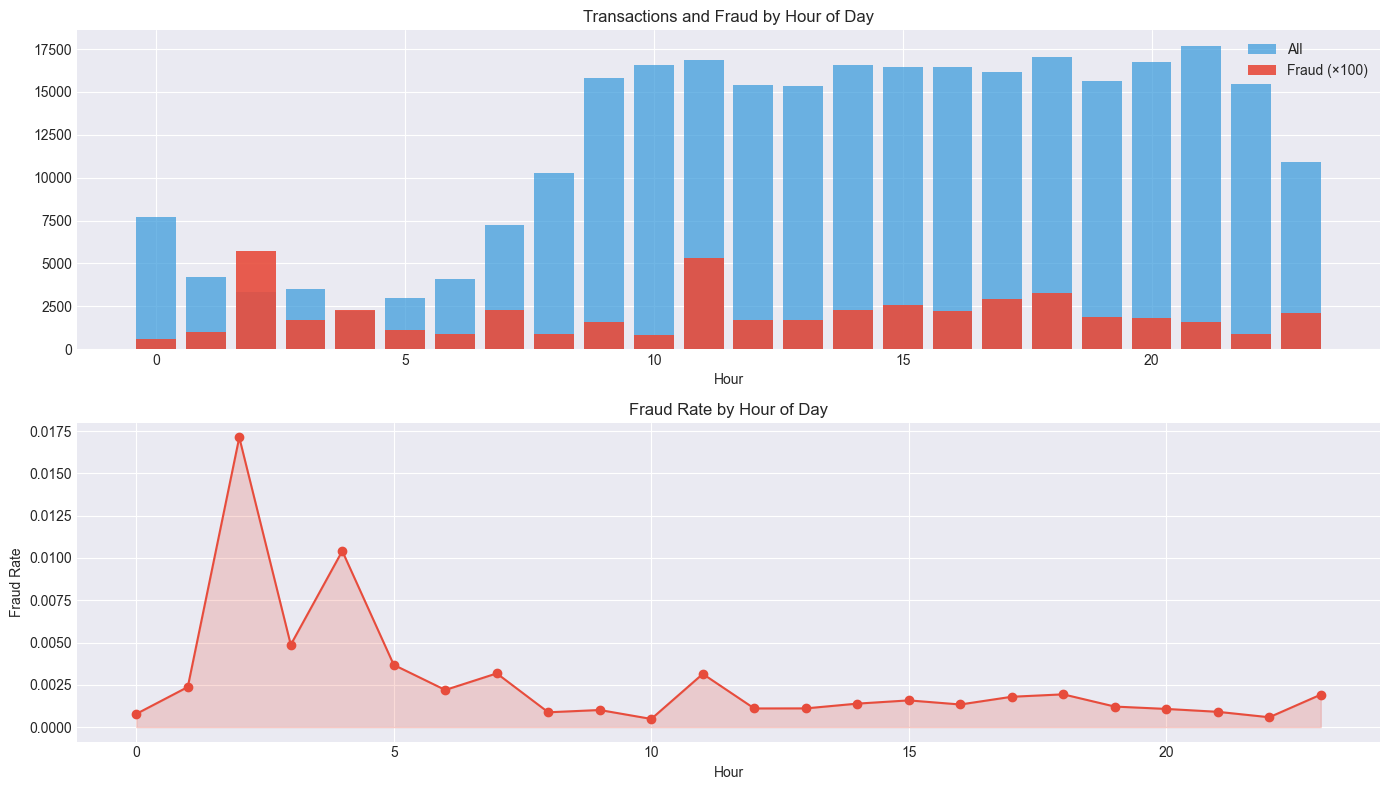

In [7]:
# Time-based analysis
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

df['hour'] = (df['Time'] // 3600) % 24

# Transactions per hour
hour_counts = df.groupby('hour')['Class'].agg(['count', 'sum'])
hour_counts.columns = ['total', 'fraud']
hour_counts['fraud_rate'] = hour_counts['fraud'] / hour_counts['total']

axes[0].bar(hour_counts.index, hour_counts['total'], color='#3498db', alpha=0.7, label='All')
axes[0].bar(hour_counts.index, hour_counts['fraud']*100, color='#e74c3c', alpha=0.9, label='Fraud (×100)')
axes[0].set_title('Transactions and Fraud by Hour of Day')
axes[0].set_xlabel('Hour')
axes[0].legend()

axes[1].plot(hour_counts.index, hour_counts['fraud_rate'], color='#e74c3c', marker='o')
axes[1].set_title('Fraud Rate by Hour of Day')
axes[1].set_xlabel('Hour')
axes[1].set_ylabel('Fraud Rate')
axes[1].fill_between(hour_counts.index, hour_counts['fraud_rate'], alpha=0.2, color='#e74c3c')

plt.tight_layout()
plt.savefig('reports/figures/time_analysis.png', dpi=150)
plt.show()


## ⚙️ 3. Feature Engineering

In [8]:
# Scale Amount and Time (V1-V28 are already PCA transformed)
scaler = RobustScaler()
df['scaled_amount'] = scaler.fit_transform(df[['Amount']])
df['scaled_time'] = scaler.fit_transform(df[['Time']])

# Add engineered features
df['log_amount'] = np.log1p(df['Amount'])
df['hour_of_day'] = (df['Time'] // 3600) % 24
df['is_night'] = ((df['hour_of_day'] >= 22) | (df['hour_of_day'] <= 6)).astype(int)

# V interaction features (top fraud-correlated features)
df['V1_x_V3'] = df['V1'] * df['V3']
df['V4_x_V11'] = df['V4'] * df['V11']
df['V12_x_V14'] = df['V12'] * df['V14']

top_v = ['V1','V3','V4','V10','V11','V12','V14','V17']
df['v_top_magnitude'] = np.sqrt((df[top_v]**2).sum(axis=1))

# Statistical features
v_cols = [c for c in df.columns if c.startswith('V')]
df['v_mean'] = df[v_cols].mean(axis=1)
df['v_std']  = df[v_cols].std(axis=1)

# Drop raw Time and Amount
df.drop(['Time', 'Amount'], axis=1, inplace=True)

print(f"Features after engineering: {df.shape[1]-1}")
print("New features:", ['scaled_amount','scaled_time','log_amount','hour_of_day',
                         'is_night','V1_x_V3','V4_x_V11','V12_x_V14','v_top_magnitude','v_mean','v_std'])


Features after engineering: 40
New features: ['scaled_amount', 'scaled_time', 'log_amount', 'hour_of_day', 'is_night', 'V1_x_V3', 'V4_x_V11', 'V12_x_V14', 'v_top_magnitude', 'v_mean', 'v_std']


## 🧹 4. Preprocessing & Handling Class Imbalance

In [9]:
X = df.drop('Class', axis=1)
y = df['Class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.1, random_state=42, stratify=y_train
)

print(f"Train: {len(X_train):,} | Val: {len(X_val):,} | Test: {len(X_test):,}")
print(f"Train fraud rate: {y_train.mean():.4f}")


Train: 205,060 | Val: 22,785 | Test: 56,962
Train fraud rate: 0.0017


Before SMOTE — Fraud: 355 | Legit: 204,705
After SMOTE  — Fraud: 204,705 | Legit: 204,705


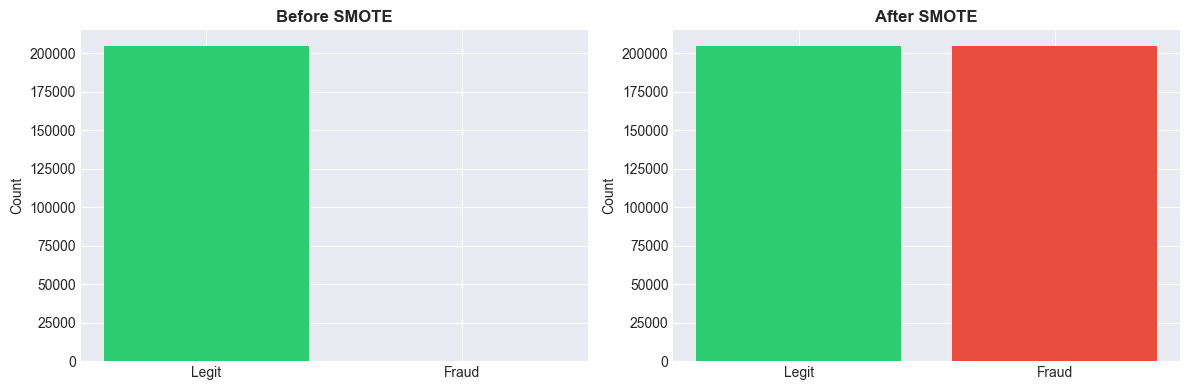

In [10]:
# Apply SMOTE to training set only (never to val/test)
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print(f"Before SMOTE — Fraud: {y_train.sum():,} | Legit: {(y_train==0).sum():,}")
print(f"After SMOTE  — Fraud: {y_train_res.sum():,} | Legit: {(y_train_res==0).sum():,}")

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, y_data, title in zip(axes, [y_train, y_train_res], ['Before SMOTE', 'After SMOTE']):
    counts = y_data.value_counts()
    ax.bar(['Legit', 'Fraud'], counts.values, color=['#2ecc71', '#e74c3c'])
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel('Count')
plt.tight_layout()
plt.show()


## 🤖 5. Model Training & Comparison

In [13]:
def find_optimal_threshold(y_true, y_proba):
    from sklearn.metrics import precision_recall_curve
    precisions, recalls, thresholds = precision_recall_curve(y_true, y_proba)
    f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-8)
    best_idx = np.argmax(f1_scores[:-1])
    return thresholds[best_idx], f1_scores[best_idx]

models = {
    "Logistic Regression": LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42, n_jobs=-1),
    "XGBoost": XGBClassifier(n_estimators=200, scale_pos_weight=577, learning_rate=0.05, random_state=42, verbosity=0),
    "LightGBM": LGBMClassifier(n_estimators=200, class_weight='balanced', learning_rate=0.05, random_state=42, verbose=-1),
}

results = {}
mlflow.set_experiment("credit_card_fraud")

for name, model in models.items():
    print(f"Training {name}...", end=" ")
    with mlflow.start_run(run_name=name):
        model.fit(X_train_res, y_train_res)
        y_proba = model.predict_proba(X_val)[:, 1]
        threshold, best_f1 = find_optimal_threshold(y_val, y_proba)
        y_pred = (y_proba >= threshold).astype(int)

        metrics = {
            "roc_auc": roc_auc_score(y_val, y_proba),
            "avg_precision": average_precision_score(y_val, y_proba),
            "f1": f1_score(y_val, y_pred),
        }
        mlflow.log_metrics(metrics)
        mlflow.sklearn.log_model(model, name)
        results[name] = {"model": model, "threshold": threshold, "metrics": metrics, "proba_val": y_proba}
        print(f"ROC-AUC: {metrics['roc_auc']:.4f} | AP: {metrics['avg_precision']:.4f} | F1: {metrics['f1']:.4f}")

print("\n✅ All models trained!")


Training Logistic Regression... ROC-AUC: 0.9398 | AP: 0.6077 | F1: 0.7500
Training Random Forest... ROC-AUC: 0.9351 | AP: 0.7921 | F1: 0.8378
Training XGBoost... ROC-AUC: 0.9168 | AP: 0.7690 | F1: 0.8108
Training LightGBM... ROC-AUC: 0.9525 | AP: 0.8028 | F1: 0.8611

✅ All models trained!



Model Comparison:
                     roc_auc  avg_precision     f1
LightGBM              0.9525         0.8028 0.8611
Random Forest         0.9351         0.7921 0.8378
XGBoost               0.9168         0.7690 0.8108
Logistic Regression   0.9398         0.6077 0.7500


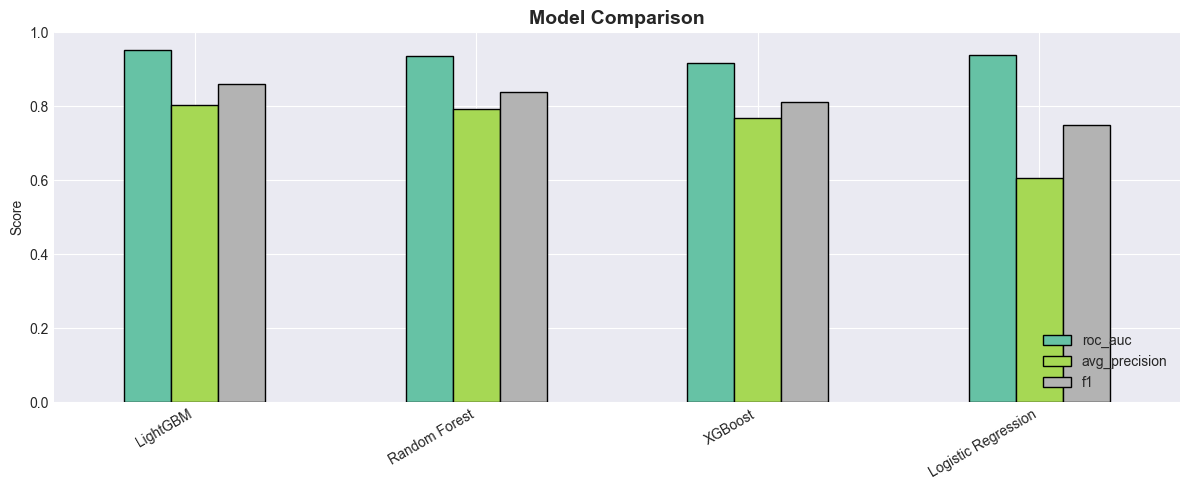

In [14]:
# Compare Models
metrics_df = pd.DataFrame({
    name: result['metrics'] for name, result in results.items()
}).T.sort_values('avg_precision', ascending=False)

print("\nModel Comparison:")
print(metrics_df.round(4).to_string())

# Bar chart comparison
metrics_df.plot(kind='bar', figsize=(12, 5), colormap='Set2', edgecolor='black')
plt.title('Model Comparison', fontsize=14, fontweight='bold')
plt.xticks(rotation=30, ha='right')
plt.ylabel('Score')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('reports/figures/model_comparison.png', dpi=150)
plt.show()


## 📊 6. Evaluation & Explainability

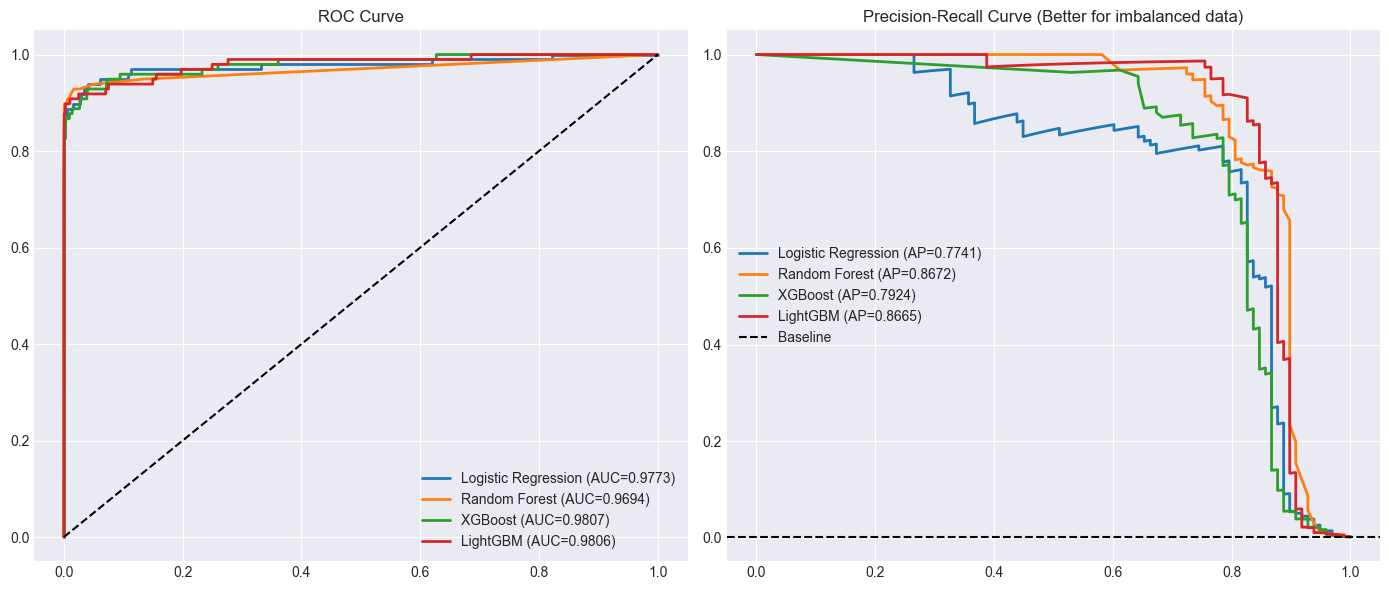

In [15]:
# ROC and PR curves
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for name, result in results.items():
    y_proba = result['model'].predict_proba(X_test)[:, 1]

    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    axes[0].plot(fpr, tpr, lw=2, label=f"{name} (AUC={auc:.4f})")

    prec, rec, _ = precision_recall_curve(y_test, y_proba)
    ap = average_precision_score(y_test, y_proba)
    axes[1].plot(rec, prec, lw=2, label=f"{name} (AP={ap:.4f})")

axes[0].plot([0,1],[0,1],'k--'); axes[0].set_title('ROC Curve'); axes[0].legend()
axes[1].axhline(y_test.mean(), color='k', linestyle='--', label='Baseline')
axes[1].set_title('Precision-Recall Curve (Better for imbalanced data)'); axes[1].legend()

for ax in axes:
    ax.set_xlabel(ax.get_xlabel() or ''); ax.grid(True)

plt.tight_layout()
plt.savefig('reports/figures/roc_pr_curves.png', dpi=150)
plt.show()


In [16]:
# Best model final test evaluation
best_name = max(results, key=lambda k: results[k]['metrics']['avg_precision'])
best_model = results[best_name]['model']
best_threshold = results[best_name]['threshold']

print(f"Best Model: {best_name}")
y_test_proba = best_model.predict_proba(X_test)[:, 1]
y_test_pred = (y_test_proba >= best_threshold).astype(int)

print(f"\nTest Set Results (threshold={best_threshold:.4f}):")
print(f"ROC-AUC:         {roc_auc_score(y_test, y_test_proba):.4f}")
print(f"Avg Precision:   {average_precision_score(y_test, y_test_proba):.4f}")
print(f"F1 Score:        {f1_score(y_test, y_test_pred):.4f}")
print(f"Fraud Caught:    {y_test_pred[y_test==1].sum()} / {y_test.sum()}")
print(f"False Alarms:    {y_test_pred[y_test==0].sum()}")
print("\nClassification Report:")
print(classification_report(y_test, y_test_pred, target_names=['Legitimate','Fraud']))


Best Model: LightGBM

Test Set Results (threshold=0.9398):
ROC-AUC:         0.9806
Avg Precision:   0.8665
F1 Score:        0.8462
Fraud Caught:    77 / 98
False Alarms:    7

Classification Report:
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     56864
       Fraud       0.92      0.79      0.85        98

    accuracy                           1.00     56962
   macro avg       0.96      0.89      0.92     56962
weighted avg       1.00      1.00      1.00     56962



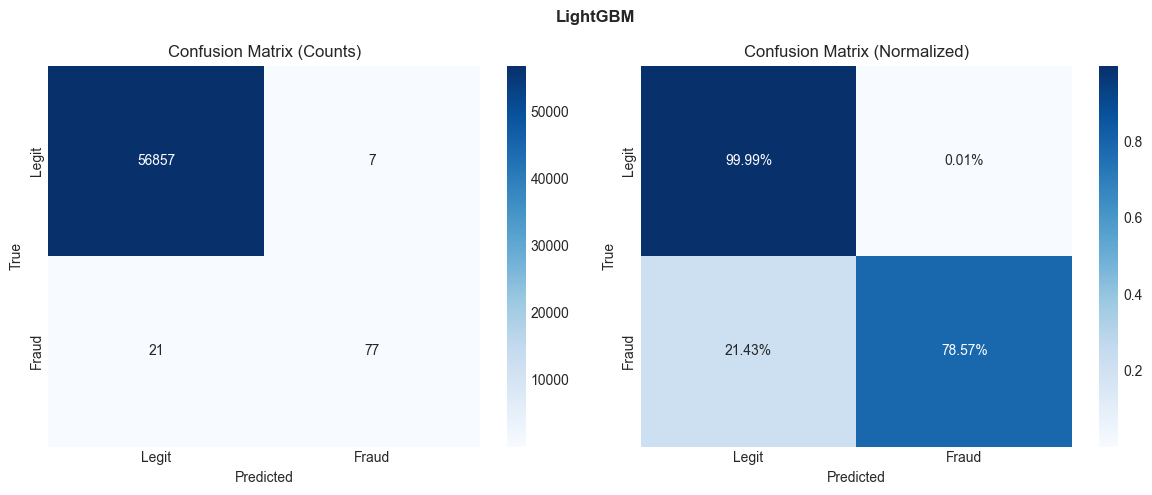

In [17]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_test_pred)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, data, fmt, title in zip(axes,
    [cm, cm/cm.sum(axis=1, keepdims=True)],
    ['d', '.2%'], ['Counts', 'Normalized']):
    sns.heatmap(data, annot=True, fmt=fmt, cmap='Blues', ax=ax,
                xticklabels=['Legit','Fraud'], yticklabels=['Legit','Fraud'])
    ax.set_title(f'Confusion Matrix ({title})')
    ax.set_ylabel('True'); ax.set_xlabel('Predicted')
plt.suptitle(f'{best_name}', fontweight='bold')
plt.tight_layout()
plt.savefig('reports/figures/confusion_matrix.png', dpi=150)
plt.show()


Computing SHAP values...


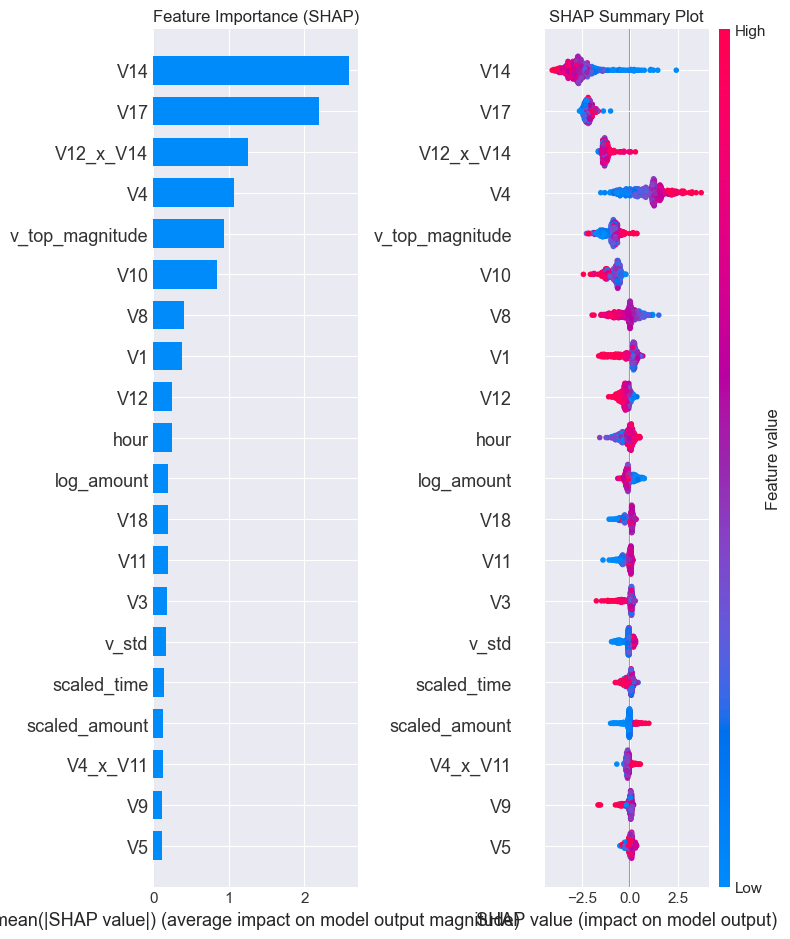

✅ SHAP analysis complete — this is what makes your project stand out!


In [18]:
# SHAP Explainability — WHY did the model predict fraud?
print("Computing SHAP values...")
sample = X_test.sample(500, random_state=42)
explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(sample)

sv = shap_values[1] if isinstance(shap_values, list) else shap_values

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
plt.sca(axes[0]); shap.summary_plot(sv, sample, plot_type='bar', show=False)
axes[0].set_title('Feature Importance (SHAP)')
plt.sca(axes[1]); shap.summary_plot(sv, sample, show=False)
axes[1].set_title('SHAP Summary Plot')
plt.tight_layout()
plt.savefig('reports/figures/shap_analysis.png', dpi=150)
plt.show()
print("✅ SHAP analysis complete — this is what makes your project stand out!")


## 🚀 7. Save Model & Deploy with FastAPI

In [21]:
import joblib, os
os.makedirs('saved_models', exist_ok=True)

artifact = {
    'model': best_model,
    'threshold': best_threshold,
    'feature_names': list(X_train.columns),
    'model_name': best_name.lower().replace(' ', '_'),
}
path = f"saved_models/{artifact['model_name']}.joblib"
joblib.dump(artifact, path)
print(f"✅ Model saved to: {path}")
print(f"\nTo run the API:")
print("  uvicorn src.api.main:app --reload")
print("  OR")
print("  docker-compose up --build")
print("\nAPI Docs available at: http://localhost:8000/docs")


✅ Model saved to: saved_models/lightgbm.joblib

To run the API:
  uvicorn src.api.main:app --reload
  OR
  docker-compose up --build

API Docs available at: http://localhost:8000/docs
